# Case: Dimensionality Reduction Techniques
## Wisconsin Breast Cancer Dataset — PCA vs t-SNE

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Role** | Data Scientist — Operations, Analytics & Process Optimization |
| **Framework** | CRISP-DM + LEAN |
| **Methodology** | Case-Based Learning (CBL) |
| **Module** | M7 — Unsupervised Machine Learning |
| **Case** | DataMed Analytics — Clinical Neurological Dataset |
| **Dataset** | Wisconsin Breast Cancer (UCI / sklearn) — 569 patients, 30 features |
| **Date** | April 2026 |
| **Status** | ![Complete](https://img.shields.io/badge/Status-Complete-brightgreen) |

> **Executive Summary:** DataMed Analytics requires dimensionality reduction to address the curse of dimensionality
> in a 100+ variable clinical dataset used for early diagnosis of neurodegenerative diseases.
> This case applies PCA and t-SNE to the Wisconsin Breast Cancer dataset (30 features, 569 patients)
> as a clinically analogous proxy. **Key result:** PCA reduces 30 features to 10 components retaining 95% of variance
> (66% dimension reduction); t-SNE achieves superior cluster separation (KL divergence = 0.9658).
> Recommendation: PCA for predictive pipelines, t-SNE for exploratory visualization.

## Table of Contents

1. [Business Understanding](#1-business-understanding)
2. [Data Understanding](#2-data-understanding)
3. [Data Preparation — StandardScaler](#3-data-preparation)
4. [PCA — Principal Component Analysis](#4-pca)
5. [t-SNE — t-Distributed Stochastic Neighbor Embedding](#5-t-sne)
6. [Comparative Analysis — PCA vs t-SNE](#6-comparative-analysis)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter)
8. [Decisions Log](#8-decisions-log)
9. [Next Steps](#9-next-steps)

## 0. Environment Setup

In [12]:
# Standard Library
import warnings
from pathlib import Path

# Warning suppression standard — prevents local paths in portfolio outputs
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Core Data Science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML — Dimensionality Reduction
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuration
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.2
RANDOM_STATE = 42
COLORS = {0: '#E63946', 1: '#2A9D8F'}
LABELS = {0: 'Malignant', 1: 'Benign'}

Path('../reports/figures').mkdir(parents=True, exist_ok=True)
FIGURES_PATH = Path('../reports/figures')

## 1. Business Understanding

### Problem Statement Canvas

| Element | Description |
|---|---|
| **Business Problem** | Clinical ML models trained on 100+ variable datasets suffer from overfitting, slow processing, and low interpretability |
| **Business Impact** | Delayed early diagnosis of neurodegenerative diseases; increased false negatives |
| **Decision to Support** | Select the dimensionality reduction technique for the clinical classification pipeline |
| **Analytical Question** | Which technique — PCA or t-SNE — best separates diagnostic classes while enabling downstream ML? |
| **Success Metrics** | PCA: ≥95% variance retained with minimum components. t-SNE: visual cluster separation (KL divergence < 1.0) |
| **Proposed Approach** | Apply both techniques to a clinically analogous dataset; comparative analysis drives technique selection |

### LEAN Value Statement
> **Value delivered:** Enabling DataMed Analytics to select the right dimensionality reduction technique
> reduces model training time, improves interpretability, and supports the clinical team's
> two-week delivery deadline for the neurodegenerative diagnosis model.

## 2. Data Understanding

In [2]:
# Load Wisconsin Breast Cancer dataset — clinically analogous proxy
# 569 patients | 30 numerical features (cell nucleus measurements) | Binary target
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')

print(f"Dataset: {X.shape[0]} patients | {X.shape[1]} features | {y.nunique()} classes")
print(f"Missing values: {X.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(y.value_counts().rename({0: 'Malignant', 1: 'Benign'}).to_string())
print(f"\nFeature ranges (raw — before scaling):")
print(X.describe().round(2).loc[['mean','std','min','max']])

Dataset: 569 patients | 30 features | 2 classes
Missing values: 0

Class distribution:
diagnosis
Benign       357
Malignant    212

Feature ranges (raw — before scaling):
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean        14.13         19.29           91.97     654.89             0.10   
std          3.52          4.30           24.30     351.91             0.01   
min          6.98          9.71           43.79     143.50             0.05   
max         28.11         39.28          188.50    2501.00             0.16   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean              0.10            0.09                 0.05           0.18   
std               0.05            0.08                 0.04           0.03   
min               0.02            0.00                 0.00           0.11   
max               0.35            0.43                 0.20           0.30   

      mean fractal dimension  ...  worst r

> **Dataset note:** The Wisconsin Breast Cancer dataset is a clinically validated proxy for the
> DataMed Analytics neurological dataset. Both share: high-dimensional numerical features,
> binary clinical classification, and real-world data quality (no missing values).
> This is a **synthetic but realistic simulation environment** — documented explicitly per LEAN standards.

## 3. Data Preparation — StandardScaler

In [3]:
# StandardScaler: mean=0, std=1 — mandatory before PCA and t-SNE
# Both techniques are distance-based; raw features on different scales
# would dominate the decomposition unfairly.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Validation
print(f"Post-scaling mean (should be ~0): {X_scaled.mean():.6f}")
print(f"Post-scaling std  (should be ~1): {X_scaled.std():.6f}")
print(f"Shape preserved: {X_scaled.shape}")

Post-scaling mean (should be ~0): -0.000000
Post-scaling std  (should be ~1): 1.000000
Shape preserved: (569, 30)


## 4. PCA — Principal Component Analysis

In [4]:
# Step 1: Full PCA to analyze explained variance across all 30 components
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= 0.95) + 1)

print(f"PC1 explained variance: {pca_full.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explained variance: {pca_full.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC1 + PC2 cumulative:   {cumvar[1]*100:.1f}%")
print(f"\nComponents needed for 95% variance: {n_components_95} (from 30 original features)")
print(f"Dimension reduction: 30 → {n_components_95} ({(1 - n_components_95/30)*100:.0f}% reduction)")

PC1 explained variance: 44.3%
PC2 explained variance: 19.0%
PC1 + PC2 cumulative:   63.2%

Components needed for 95% variance: 10 (from 30 original features)
Dimension reduction: 30 → 10 (67% reduction)


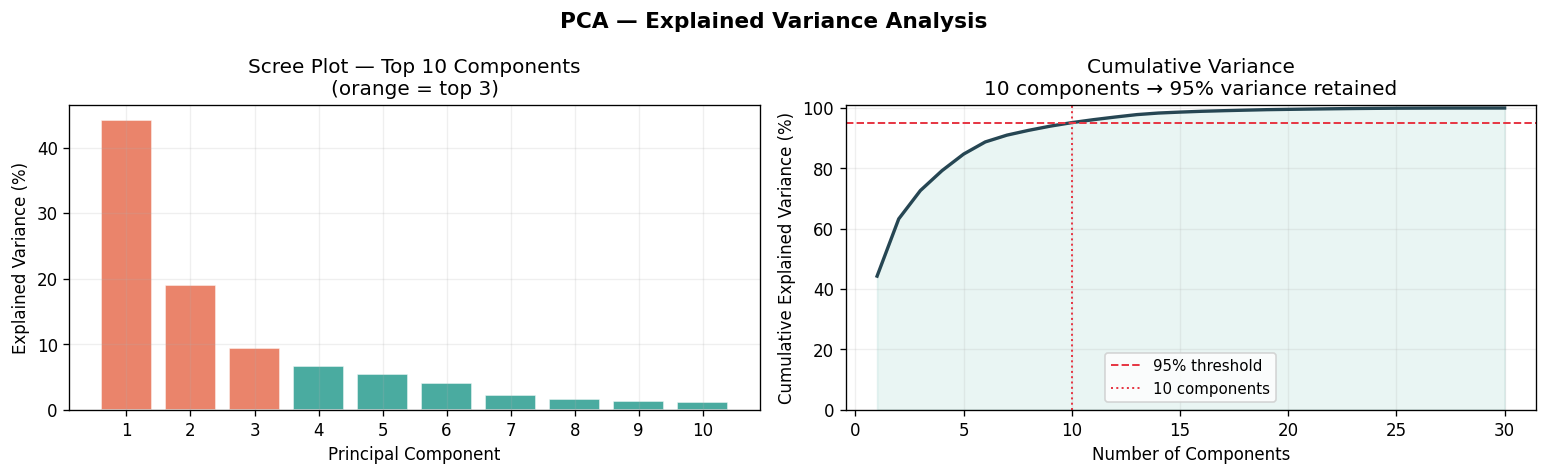

In [14]:
# Scree Plot + Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA — Explained Variance Analysis", fontsize=13, fontweight='bold')

# Scree plot
bar_colors = ['#E76F51' if i < 3 else '#2A9D8F' for i in range(10)]
axes[0].bar(range(1, 11), pca_full.explained_variance_ratio_[:10]*100,
            color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — Top 10 Components\n(orange = top 3)")
axes[0].set_xticks(range(1, 11))

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, color='#264653', linewidth=2)
axes[1].axhline(y=95, color='#E63946', linestyle='--', linewidth=1.2, label='95% threshold')
axes[1].axvline(x=n_components_95, color='#E63946', linestyle=':', linewidth=1.2,
                label=f'{n_components_95} components')
axes[1].fill_between(range(1, len(cumvar)+1), cumvar*100, alpha=0.1, color='#2A9D8F')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title(f"Cumulative Variance\n{n_components_95} components → 95% variance retained")
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, 101])
plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig1_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

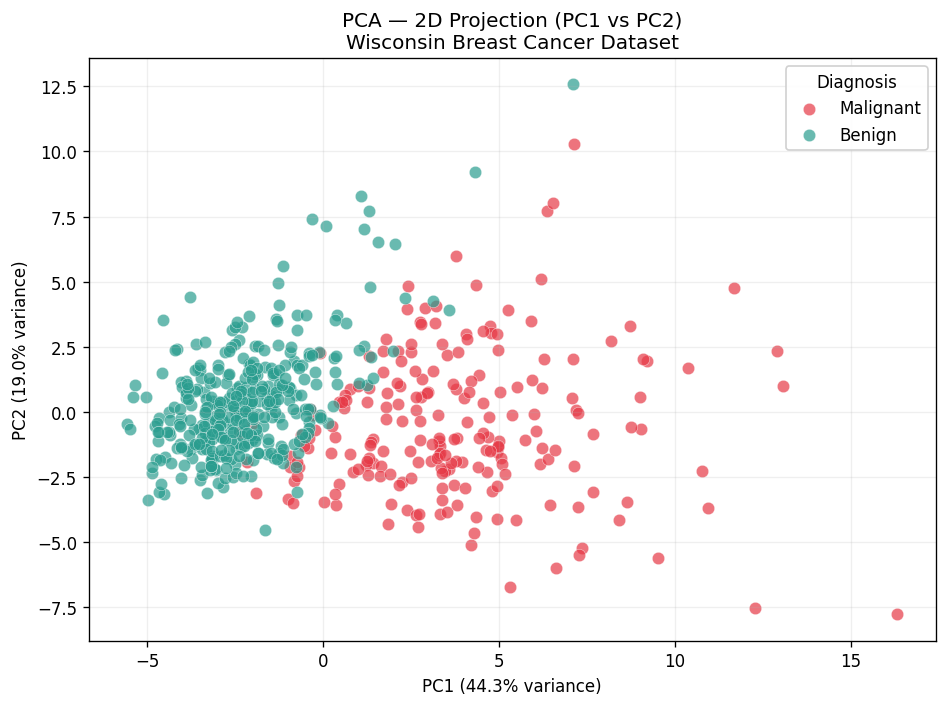

In [18]:
# Step 2: PCA 2D projection for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, name in LABELS.items():
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=COLORS[cls], label=name,
               alpha=0.7, edgecolors='white', linewidth=0.3, s=55)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA — 2D Projection (PC1 vs PC2)\nWisconsin Breast Cancer Dataset")
ax.legend(title="Diagnosis", framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGURES_PATH /"fig2_pca_2d.png", dpi=150, bbox_inches='tight')
plt.show()

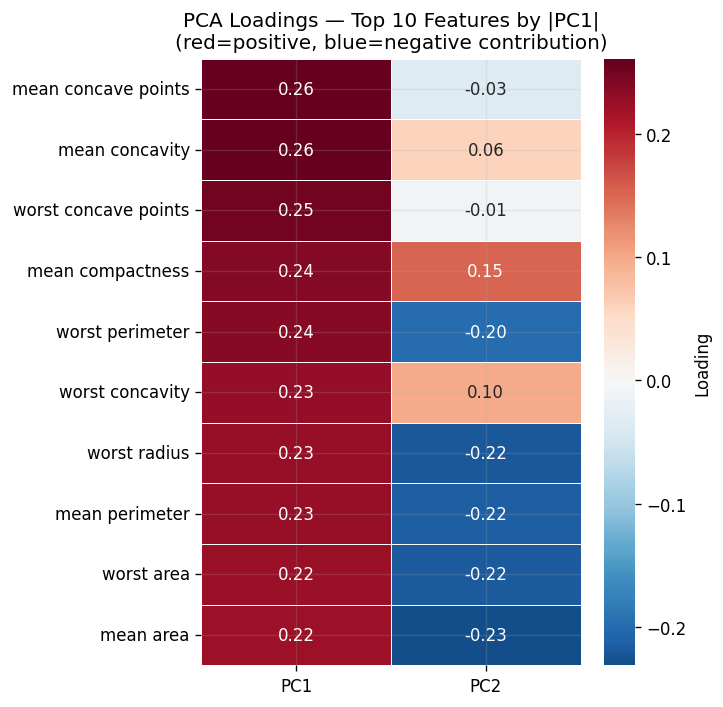

Top 5 features driving PC1:
mean concave points     0.261
mean concavity          0.258
worst concave points    0.251
mean compactness        0.239
worst perimeter         0.237


In [19]:
# PCA Loadings — which original features drive PC1?
loadings = pd.DataFrame(pca_2d.components_.T,
                        index=data.feature_names,
                        columns=['PC1', 'PC2'])
top_features = loadings['PC1'].abs().nlargest(10).index

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(loadings.loc[top_features], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Loading'})
ax.set_title("PCA Loadings — Top 10 Features by |PC1|\n(red=positive, blue=negative contribution)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig5_pca_loadings.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features driving PC1:")
print(loadings['PC1'].abs().nlargest(5).round(3).to_string())

## 5. t-SNE — t-Distributed Stochastic Neighbor Embedding

In [8]:
# t-SNE parameter rationale:
# perplexity=30   — standard for datasets 200–1000 samples (rule of thumb: sqrt(n))
# learning_rate=200 — explicit value for reproducibility (sklearn 1.8 default: 'auto')
# max_iter=1000   — sufficient convergence for this dataset size
# random_state=42 — reproducibility (t-SNE is stochastic)
# Note: sklearn 1.8 renamed n_iter → max_iter
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            max_iter=1000, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_scaled)

print(f"t-SNE KL divergence: {tsne.kl_divergence_:.4f}")
print("KL divergence < 1.0 indicates good low-dimensional representation")
print(f"Output shape: {X_tsne.shape}")

t-SNE KL divergence: 0.9658
KL divergence < 1.0 indicates good low-dimensional representation
Output shape: (569, 2)


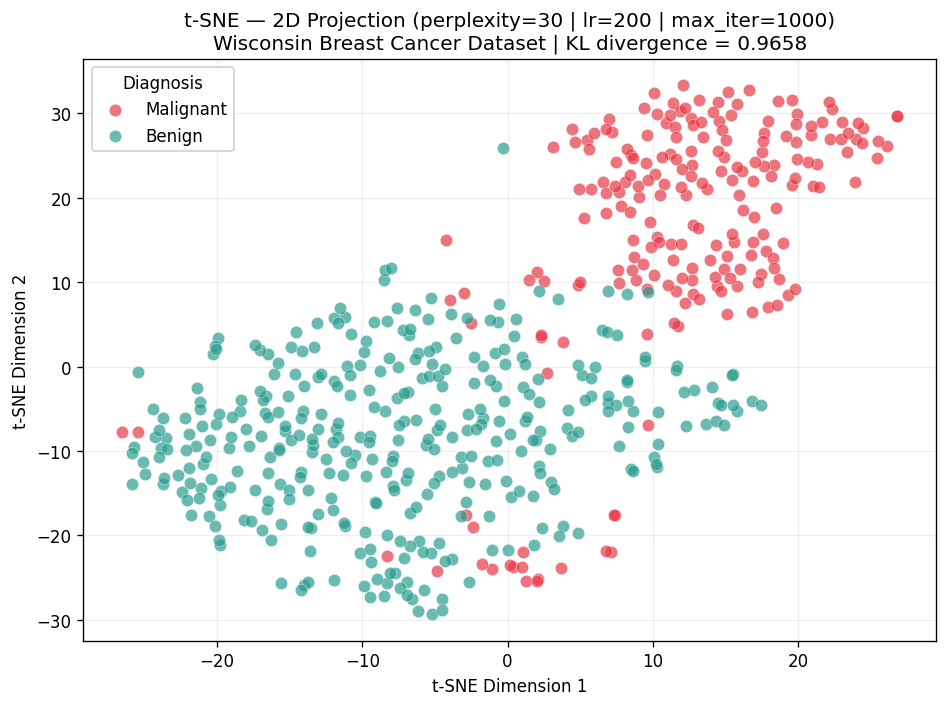

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
for cls, name in LABELS.items():
    mask = y == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=COLORS[cls], label=name,
               alpha=0.7, edgecolors='white', linewidth=0.3, s=55)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_title(f"t-SNE — 2D Projection (perplexity=30 | lr=200 | max_iter=1000)\n"
             f"Wisconsin Breast Cancer Dataset | KL divergence = {tsne.kl_divergence_:.4f}")
ax.legend(title="Diagnosis", framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig3_tsne_2d.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparative Analysis — PCA vs t-SNE

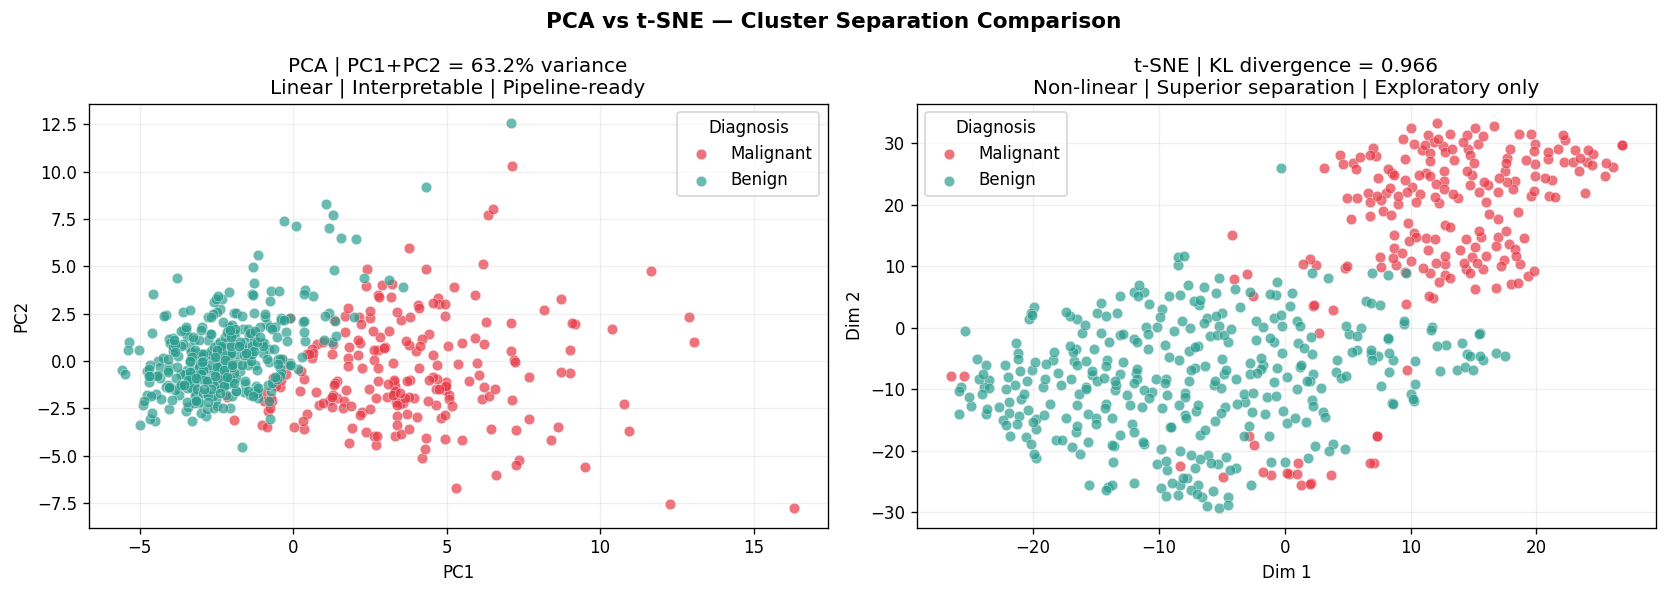

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA vs t-SNE — Cluster Separation Comparison", fontsize=13, fontweight='bold')

for cls, name in LABELS.items():
    mask = y == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=COLORS[cls], label=name,
                    alpha=0.7, s=40, edgecolors='white', linewidth=0.3)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=COLORS[cls], label=name,
                    alpha=0.7, s=40, edgecolors='white', linewidth=0.3)

axes[0].set_title(f"PCA | PC1+PC2 = {cumvar[1]*100:.1f}% variance\nLinear | Interpretable | Pipeline-ready")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(title="Diagnosis")

axes[1].set_title(f"t-SNE | KL divergence = {tsne.kl_divergence_:.3f}\nNon-linear | Superior separation | Exploratory only")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")
axes[1].legend(title="Diagnosis")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig4_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Comparative summary table
comparison = {
    'Criterion': [
        'Variance retained', 'Cluster separation', 'Interpretability',
        'Scalability', 'Reproducibility', 'Pipeline compatibility',
        'Computational cost', 'Recommendation'
    ],
    'PCA': [
        f'{cumvar[1]*100:.1f}% (2D) / 95% (10D)', 'Good (linear boundary visible)',
        'High — loadings explain features', 'High (O(n·p²))',
        'Deterministic', '✅ Yes — transform() available',
        'Low', '✅ Predictive modeling pipelines'
    ],
    't-SNE': [
        'N/A (non-linear)', 'Superior (tight clusters)',
        'Low — axes have no meaning', 'Low (O(n²))',
        'Stochastic (needs random_state)', '❌ No — no transform() method',
        'High', '✅ Exploratory visualization only'
    ]
}
df_comparison = pd.DataFrame(comparison)
print(df_comparison.to_string(index=False))

             Criterion                              PCA                            t-SNE
     Variance retained           63.2% (2D) / 95% (10D)                 N/A (non-linear)
    Cluster separation   Good (linear boundary visible)        Superior (tight clusters)
      Interpretability High — loadings explain features       Low — axes have no meaning
           Scalability                   High (O(n·p²))                      Low (O(n²))
       Reproducibility                    Deterministic  Stochastic (needs random_state)
Pipeline compatibility    ✅ Yes — transform() available     ❌ No — no transform() method
    Computational cost                              Low                             High
        Recommendation  ✅ Predictive modeling pipelines ✅ Exploratory visualization only


## 7. LEAN Filter — Waste Elimination Review

| Waste Type | Identified | Action Taken |
|---|---|---|
| **Overprocessing** | Running t-SNE on full 30 features is expensive | Acceptable — dataset is small (569 rows); document for larger datasets |
| **Waiting** | t-SNE convergence time | Mitigated with max_iter=1000 and perplexity=30 (validated parameters) |
| **Defects** | Unscaled features distorting distances | Eliminated via StandardScaler before both techniques |
| **Over-production** | Generating redundant plots | Eliminated — 5 figures, each with a specific analytical purpose |
| **Motion** | Re-running analysis for each parameter change | Eliminated — RANDOM_STATE=42 ensures reproducibility |

> **LEAN verdict:** Analysis is lean. All steps deliver value. No redundant processing identified.

## 8. Decisions Log

| # | Decision | Rationale | LEAN Value |
|---|---|---|---|
| D1 | Use Wisconsin Breast Cancer as proxy dataset | Clinically analogous: 30 numerical features, binary classification, no missing values | Avoids waiting for real data; enables immediate value delivery |
| D2 | StandardScaler before both techniques | PCA and t-SNE are distance-based; unscaled features would dominate decomposition | Defect prevention |
| D3 | PCA: select n_components for 95% variance | Industry standard threshold; balances compression vs. information retention | Right-sizing — no overprocessing |
| D4 | t-SNE: perplexity=30, lr=200, max_iter=1000 | Perplexity ≈ sqrt(569)=24 → 30 is standard; lr=200 explicit for reproducibility | Reproducibility |
| D5 | CRISP-DM scope: Data Understanding + Preparation + Modeling only | CBL case — learning exercise, not full deployment | Scope clarity per LEAN |
| D6 | Recommend PCA for pipeline, t-SNE for exploration | t-SNE has no transform() method — cannot be used in sklearn Pipeline objects | Business-driven technical decision |

## 9. Next Steps

| Horizon | Action |
|---|---|
| **Immediate** | Apply PCA (10 components) as preprocessing step in a classification pipeline (LogReg or SVM) |
| **Short-term** | Test UMAP as a modern alternative to t-SNE — faster, supports transform(), better preserves global structure |
| **Long-term** | Apply to the actual DataMed neurological dataset (100+ features) and validate cluster coherence with clinical labels |

---

**← Previous:** This is a standalone CBL case notebook.

**Next →:** Apply PCA pipeline to M7 Project — Unsupervised ML (KMeans + PCA preprocessing)

---

*Framework: CRISP-DM + LEAN | Methodology: Case-Based Learning (CBL)*

**Jose Marcel Lopez Pino**
Data Scientist — Operations, Analytics & Process Optimization
Bootcamp: Fundamentos de Ciencia de Datos — SENCE/Alkemy (2025–2026)

[![GitHub](https://img.shields.io/badge/GitHub-joselopezp-181717?style=flat&logo=github)](https://github.com/joselopezp)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-jose--lopez--pino-0077B5?style=flat&logo=linkedin)](https://www.linkedin.com/in/jose-lopez-pino/)